## Установим библиотеки и загрузим данные

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import ceil
import warnings

warnings.filterwarnings('ignore')

# Загрузка данных 
try:
    df = pd.read_csv('student_habits_performance.csv')
    print("Данные успешно загружены.")
except FileNotFoundError:
    print("Файл 'student_performance.csv' не найден. Пожалуйста, проверь путь.")
   

# Удалим ID, так как он не нужен для моделирования
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)

print("\nПервые 5 строк данных:")
print(df.head())

Данные успешно загружены.

Первые 5 строк данных:
   age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0   23  Female                  0.0                 1.2            1.1   
1   20  Female                  6.9                 2.8            2.3   
2   21    Male                  1.4                 3.1            1.3   
3   23  Female                  1.0                 3.9            1.0   
4   19  Female                  5.0                 4.4            0.5   

  part_time_job  attendance_percentage  sleep_hours diet_quality  \
0            No                   85.0          8.0         Fair   
1            No                   97.3          4.6         Good   
2            No                   94.8          8.0         Poor   
3            No                   71.0          9.2         Poor   
4            No                   90.9          4.9         Fair   

   exercise_frequency parental_education_level internet_quality  \
0                   6        

## Проанализируем данные


Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating    

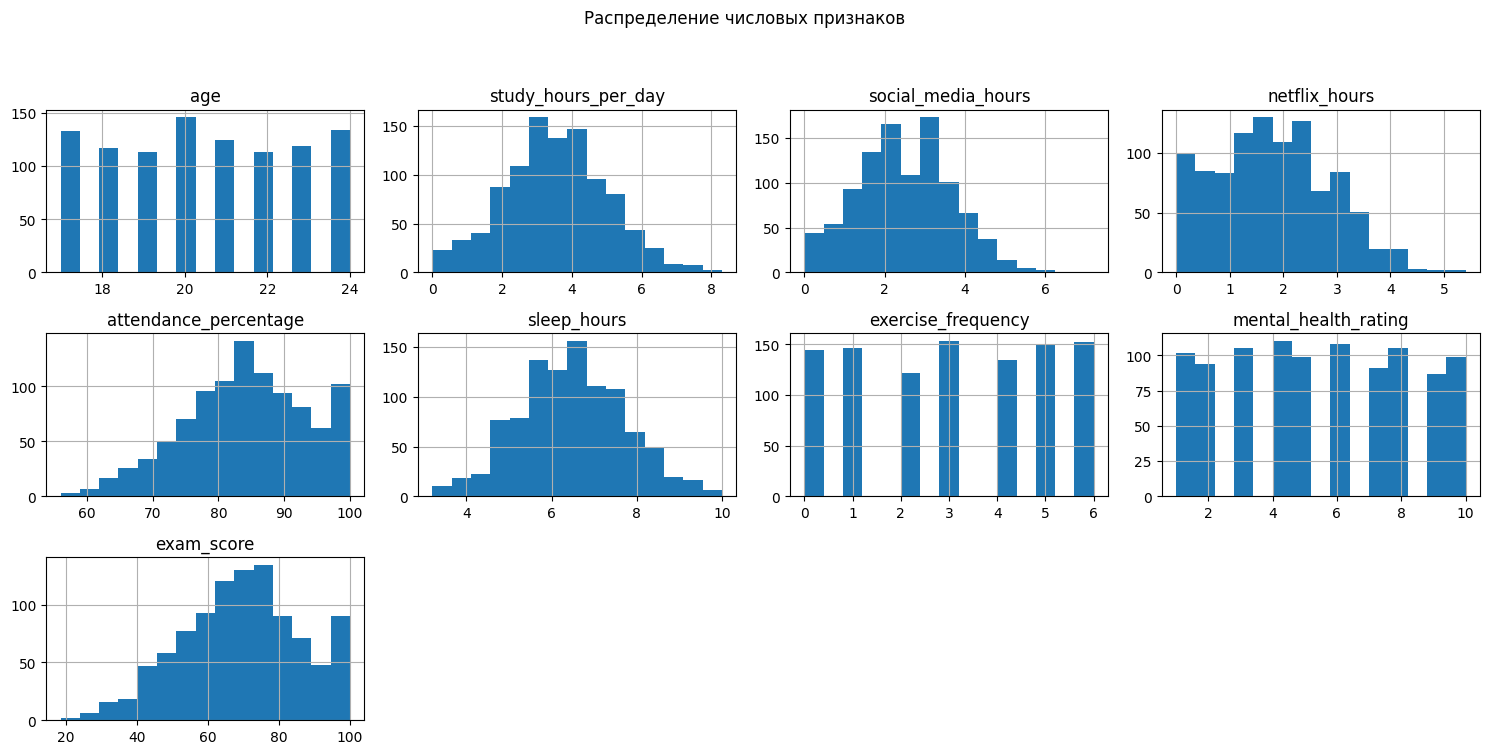

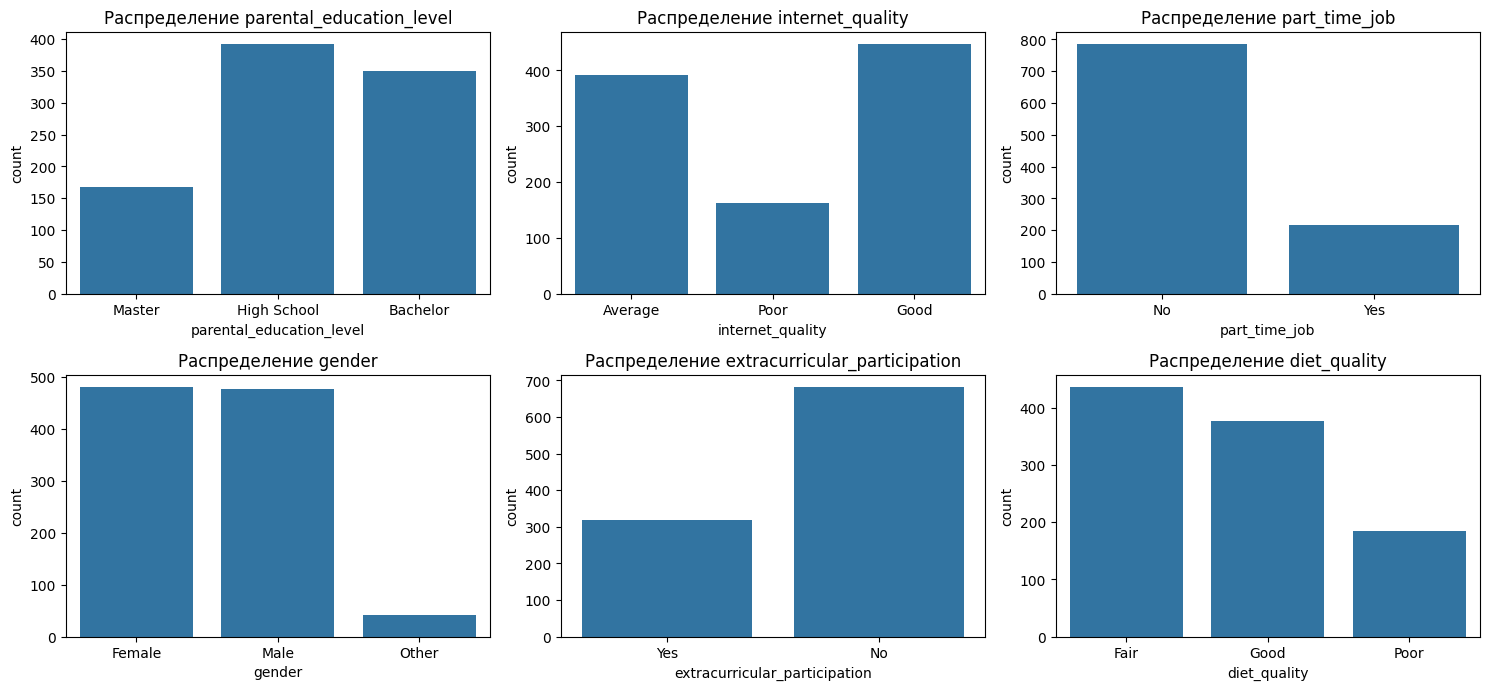

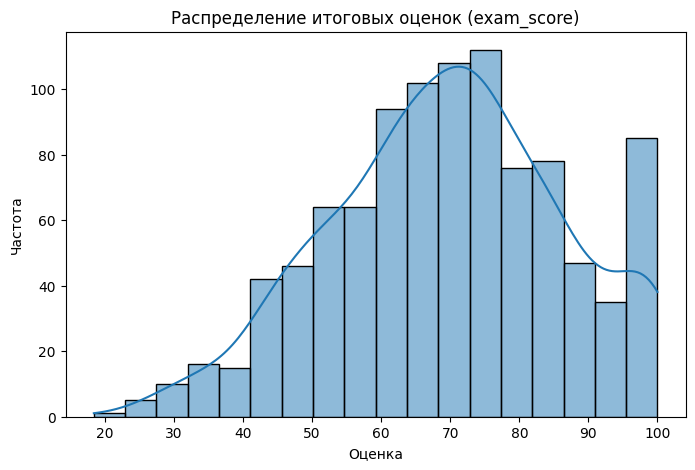

In [2]:
print("\nИнформация о DataFrame:")
df.info()

print("\nОписательная статистика:")
print(df.describe())

print("\nКоличество пропущенных значений:")
print(df.isnull().sum())

# Визуализация распределений числовых признаков
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
# Уберем бинарные признаки 0/1, если они рассматриваются как категории
numerical_features = [col for col in numerical_features if len(df[col].unique()) > 2]

df[numerical_features].hist(bins=15, figsize=(15, 10), layout=(4, 4))
plt.suptitle("Распределение числовых признаков")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Визуализация категориальных признаков
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Добавим бинарные 0/1 и признаки с малым числом уникальных значений
categorical_features.extend([col for col in df.select_dtypes(include=np.number).columns if len(df[col].unique()) <= 5])
# Уберем дубликаты
categorical_features = list(set(categorical_features) - set(numerical_features))
# Уберем целевую переменную, если она попала сюда
if 'exam_score' in categorical_features:
    categorical_features.remove('exam_score')

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col)
    plt.title(f"Распределение {col}")
plt.tight_layout()
plt.show()

# Визуализация целевой переменной
plt.figure(figsize=(8, 5))
sns.histplot(df['exam_score'], kde=True)
plt.title("Распределение итоговых оценок (exam_score)")
plt.xlabel("Оценка")
plt.ylabel("Частота")
plt.show()



## Масштабироание, кодирование и формирование признаков

In [ ]:
# Добавляем вспомогательный признаки
df['total_screen_time'] = df['social_media_hours'] + df['netflix_hours']
df['study_leisure_ratio'] = df['study_hours_per_day'] / (df['total_screen_time'] + 1e-6)

# Определяем числовые и категориальные признаки
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('exam_score') # Удаляем целевую переменную
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Добавляем числовые признаки с малым числом уникальных значений в категориальные
maybe_cat = [col for col in numerical_cols if len(df[col].unique()) <= 5]
categorical_cols.extend(maybe_cat)
numerical_cols = [col for col in numerical_cols if col not in maybe_cat]

print(f"Числовые признаки: {numerical_cols}")
print(f"Категориальные признаки: {categorical_cols}")

# Создаем конвейеры для обработки
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Заполняем пропуски медианой
    ('scaler', StandardScaler()) # Масштабируем
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Заполняем пропуски модой
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Кодируем OHE
])

# Создаем препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Оставляем остальные столбцы (на случай, если что-то упустили)
)

# Разделяем данные на признаки (X) и целевую переменную (y)
X = df.drop('exam_score', axis=1)
y = df['exam_score']



Числовые признаки: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Категориальные признаки: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


## Корреляционный анализ

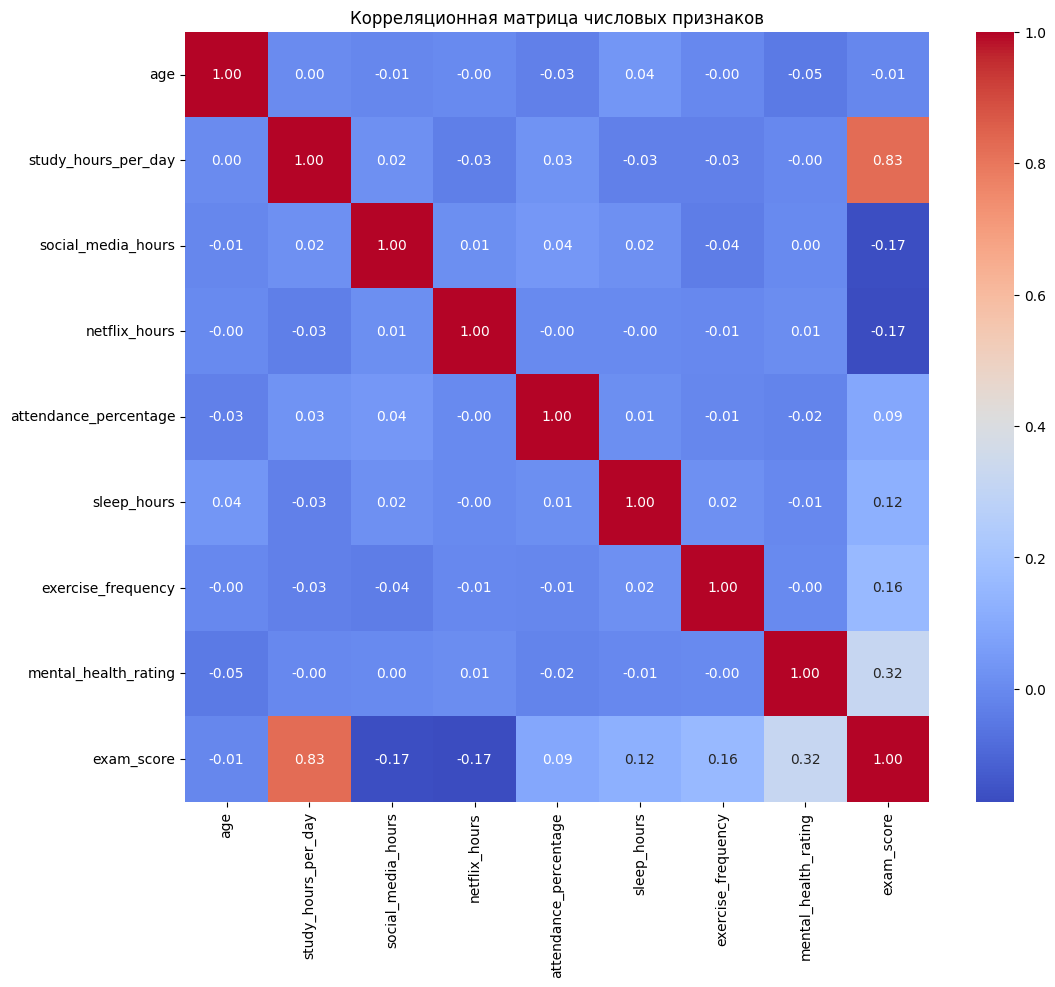


Корреляция с целевой переменной (exam_score):
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


In [4]:
# Создаем копию для анализа, чтобы не изменять оригинал
df_corr = df.copy()

# Построим heatmap для исходных числовых + целевая переменная.
plt.figure(figsize=(12, 10))
numerical_with_target = numerical_cols + ['exam_score']
correlation_matrix = df[numerical_with_target].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица числовых признаков")
plt.show()

print("\nКорреляция с целевой переменной (exam_score):")
print(correlation_matrix['exam_score'].sort_values(ascending=False))

##### Наибольшая корелляция с целевой переменной наблюдается у признаков: study_hours_per_day, study_leisure_ratio, mental_health_rating, total_screen_time

## Формирование обучающей и тестовой выборки

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (800, 16)
Размер тестовой выборки: (200, 16)


## Выбор наиболее подходящих моделей и построение базового решения

--- Linear Regression ---
MAE: 4.1930
MSE: 26.5348
R2: 0.8965

--- Ridge ---
MAE: 4.1933
MSE: 26.5478
R2: 0.8965

--- Lasso ---
MAE: 4.6333
MSE: 32.8684
R2: 0.8718

--- Decision Tree ---
MAE: 7.5515
MSE: 88.8501
R2: 0.6535

--- Random Forest ---
MAE: 5.0450
MSE: 39.0235
R2: 0.8478

--- Gradient Boosting ---
MAE: 4.7078
MSE: 33.3935
R2: 0.8698



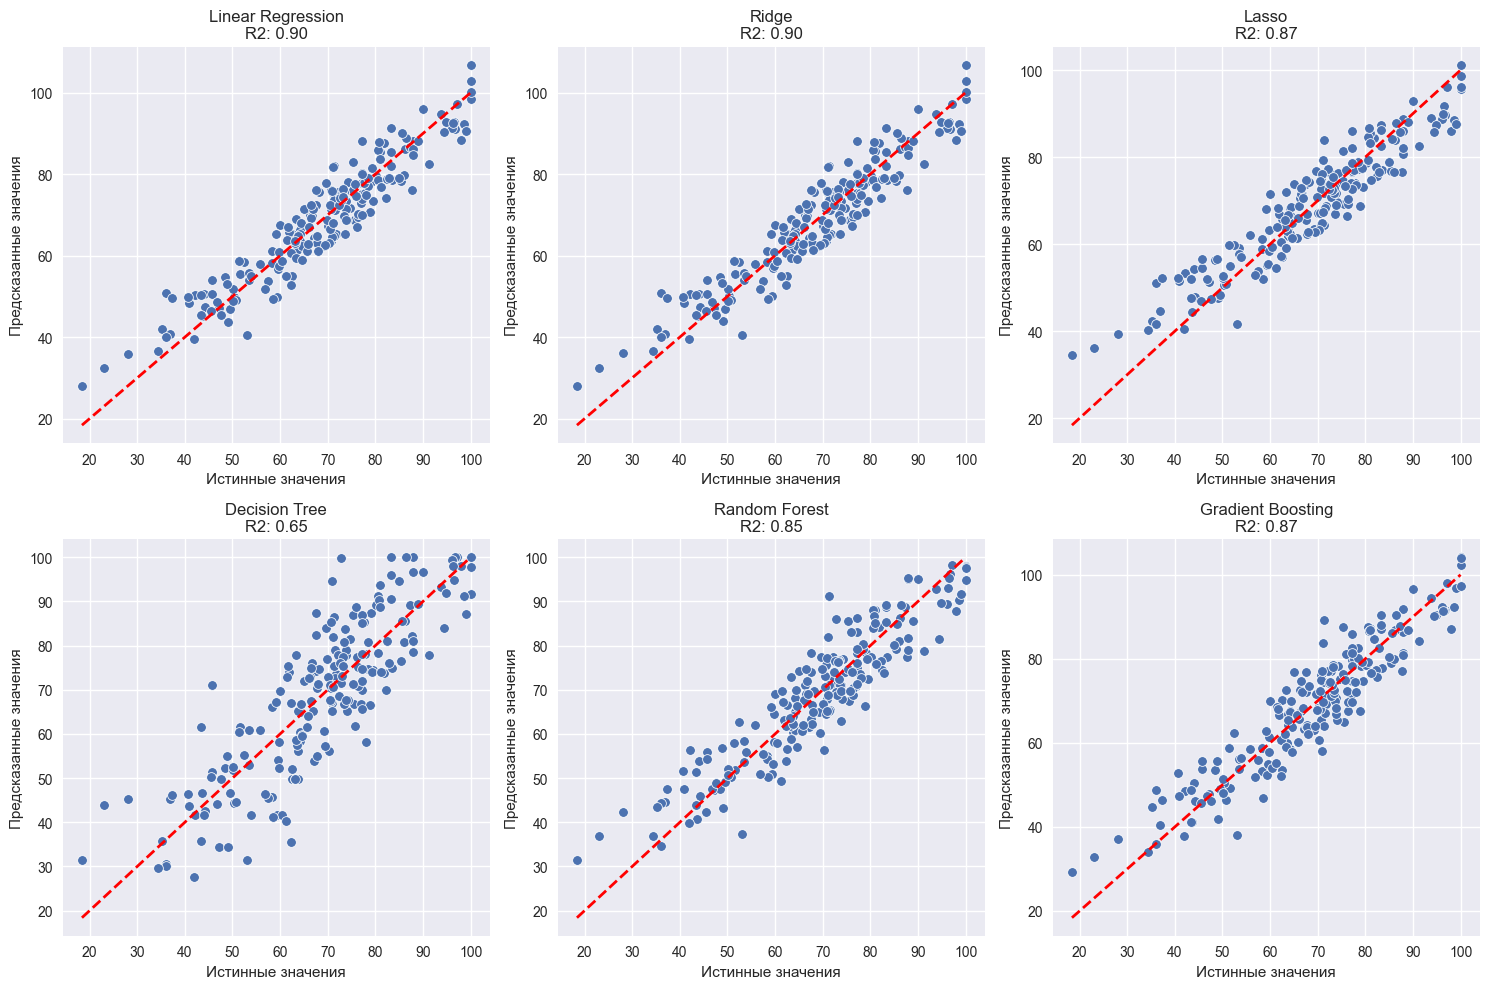


--- Baseline Results ---
                        MAE        MSE        R2
Linear Regression  4.193045  26.534844  0.896522
Ridge              4.193275  26.547820  0.896471
Lasso              4.633309  32.868432  0.871823
Decision Tree      7.551500  88.850150  0.653510
Random Forest      5.045020  39.023471  0.847820
Gradient Boosting  4.707778  33.393450  0.869775


In [29]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}

plt.figure(figsize=(15, 10)) 

for name, model in models.items():
    # Создаем полный конвейер: препроцессор + модель
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', model)])

    # Обучение
    pipeline.fit(X_train, y_train)

    # Предсказание
    y_pred = pipeline.predict(X_test)

    # Оценка
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    #Выбор метрик
    results[name] = {'MAE': mae, 'MSE': mse, 'R2': r2}
    print(f"--- {name} ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2: {r2:.4f}\n")

    # Scatter plot для каждой модели
    plt.subplot(2, 3, list(models.keys()).index(name) + 1) # 2 rows, 3 columns
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # y=x line
    plt.title(f'{name}\nR2: {r2:.2f}')
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.grid(True)

plt.tight_layout()
plt.show()

baseline_results_df = pd.DataFrame(results).T
print("\n--- Baseline Results ---")
print(baseline_results_df)

## Подбор гипперпараметров

--- Tuning Linear Regression ---
No hyperparameters to tune or grid not provided.

--- Tuning Ridge ---
Best params: {'regressor__alpha': 0.01}
Best R2 score (CV): 0.8948

--- Tuning Lasso ---
Best params: {'regressor__alpha': 0.1}
Best R2 score (CV): 0.8955

--- Tuning Decision Tree ---
Best params: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 2}
Best R2 score (CV): 0.7636

--- Tuning Random Forest ---
Best params: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Best R2 score (CV): 0.8589

--- Tuning Gradient Boosting ---
Best params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 150}
Best R2 score (CV): 0.8788



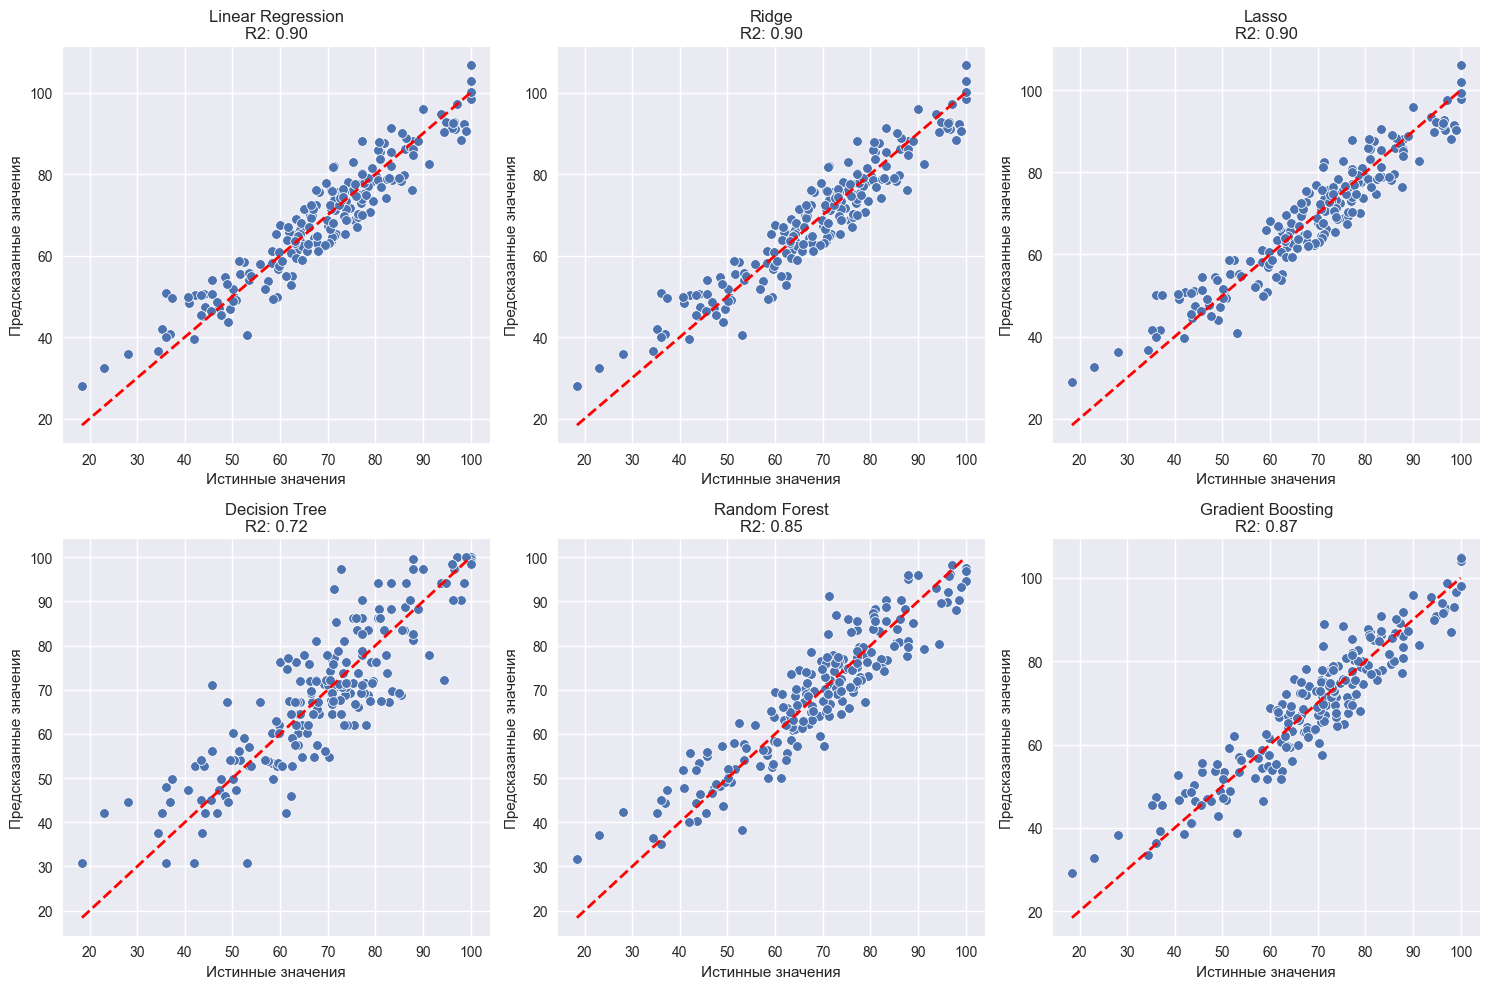


--- Best Model Evaluation Results ---
                        MAE        MSE        R2
Linear Regression  4.193045  26.534844  0.896522
Ridge              4.193047  26.534970  0.896521
Lasso              4.165817  26.292641  0.897466
Decision Tree      6.598610  71.446454  0.721379
Random Forest      4.938813  38.035156  0.851674
Gradient Boosting  4.701958  33.115348  0.870860

--- Grid Search Best Parameters ---
Linear Regression: N/A
Ridge: {'regressor__alpha': 0.01}
Lasso: {'regressor__alpha': 0.1}
Decision Tree: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 2}
Random Forest: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Gradient Boosting: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 150}


In [30]:
param_grids = {
    'Linear Regression': {},
    'Ridge': {
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
    },
    'Lasso': {
        'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'SVR': {
        'regressor__C': [0.1, 1, 10, 100, 500],
        'regressor__gamma': [0.001, 0.01, 0.1, 1, 'scale'],
        'regressor__kernel': ['rbf', 'linear']
    },
    'Decision Tree': {
        'regressor__max_depth': [None, 5, 10, 15, 20],
        'regressor__min_samples_split': [2, 5, 10, 15],
        'regressor__min_samples_leaf': [1, 2, 4, 8]
    },
    'Random Forest': {
        'regressor__n_estimators': [100, 200, 300],
        'regressor__max_depth': [10, 20, 30, None],
        'regressor__min_samples_split': [2, 5, 10],
        'regressor__min_samples_leaf': [1, 2, 4],
    },
    'Gradient Boosting': {
        'regressor__n_estimators': [50, 100, 150], 
        'regressor__learning_rate': [0.01, 0.05, 0.1], 
        'regressor__max_depth': [3, 5, 7], 
        'regressor__min_samples_split': [2, 5], 
        'regressor__min_samples_leaf': [1, 2] 
    }
}

best_models = {}
grid_search_results = {}

evaluation_results = {} 

plt.figure(figsize=(15, 10)) 

for name, model in models.items():
    print(f"--- Tuning {name} ---")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', model)])

    if name in param_grids and param_grids[name]:
        grid_search = GridSearchCV(pipeline, param_grids[name], cv=5, scoring='r2', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_models[name] = grid_search.best_estimator_
        grid_search_results[name] = grid_search.best_params_
        print(f"Best params: {grid_search.best_params_}")
        print(f"Best R2 score (CV): {grid_search.best_score_:.4f}\n")
    else:
        pipeline.fit(X_train, y_train)
        best_models[name] = pipeline
        grid_search_results[name] = 'N/A'
        print("No hyperparameters to tune or grid not provided.\n")

    
    y_pred = best_models[name].predict(X_test)

    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    evaluation_results[name] = {'MAE': mae, 'MSE': mse, 'R2': r2}

    
    plt.subplot(2, 3, list(models.keys()).index(name) + 1) 
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
    plt.title(f'{name}\nR2: {r2:.2f}')
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Best Model Evaluation Results ---")
evaluation_results_df = pd.DataFrame(evaluation_results).T
print(evaluation_results_df)

print("\n--- Grid Search Best Parameters ---")
for name, params in grid_search_results.items():
    print(f"{name}: {params}")

## Сравнение качества полученных моделей

In [31]:
tuned_results = {}

for name, model in best_models.items():
    # Предсказание
    y_pred = model.predict(X_test)

    # Оценка
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    tuned_results[name] = {'MAE': mae, 'MSE': mse, 'R2': r2}
    print(f"--- {name} (Tuned) ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2: {r2:.4f}\n")

tuned_results_df = pd.DataFrame(tuned_results).T
print("\n--- Tuned Results ---")
print(tuned_results_df)

print("\n--- Baseline Results ---")
print(baseline_results_df)

--- Linear Regression (Tuned) ---
MAE: 4.1930
MSE: 26.5348
R2: 0.8965

--- Ridge (Tuned) ---
MAE: 4.1930
MSE: 26.5350
R2: 0.8965

--- Lasso (Tuned) ---
MAE: 4.1658
MSE: 26.2926
R2: 0.8975

--- Decision Tree (Tuned) ---
MAE: 6.5986
MSE: 71.4465
R2: 0.7214

--- Random Forest (Tuned) ---
MAE: 4.9388
MSE: 38.0352
R2: 0.8517

--- Gradient Boosting (Tuned) ---
MAE: 4.7020
MSE: 33.1153
R2: 0.8709


--- Tuned Results ---
                        MAE        MSE        R2
Linear Regression  4.193045  26.534844  0.896522
Ridge              4.193047  26.534970  0.896521
Lasso              4.165817  26.292641  0.897466
Decision Tree      6.598610  71.446454  0.721379
Random Forest      4.938813  38.035156  0.851674
Gradient Boosting  4.701958  33.115348  0.870860

--- Baseline Results ---
                        MAE        MSE        R2
Linear Regression  4.193045  26.534844  0.896522
Ridge              4.193275  26.547820  0.896471
Lasso              4.633309  32.868432  0.871823
Decision Tree     

### Выводы после настройки
##### Настройка гиперпараметров дала наибольший эффект для модели Decision Tree, значительно улучшив её качество по обеим метрикам. Для Lasso также наблюдаются небольшие улучшения. В остальных моделях (Linear Regression, Ridge, Random Forest, Gradient Boosting) влияние тюнинга минимально

<Figure size 1200x600 with 0 Axes>

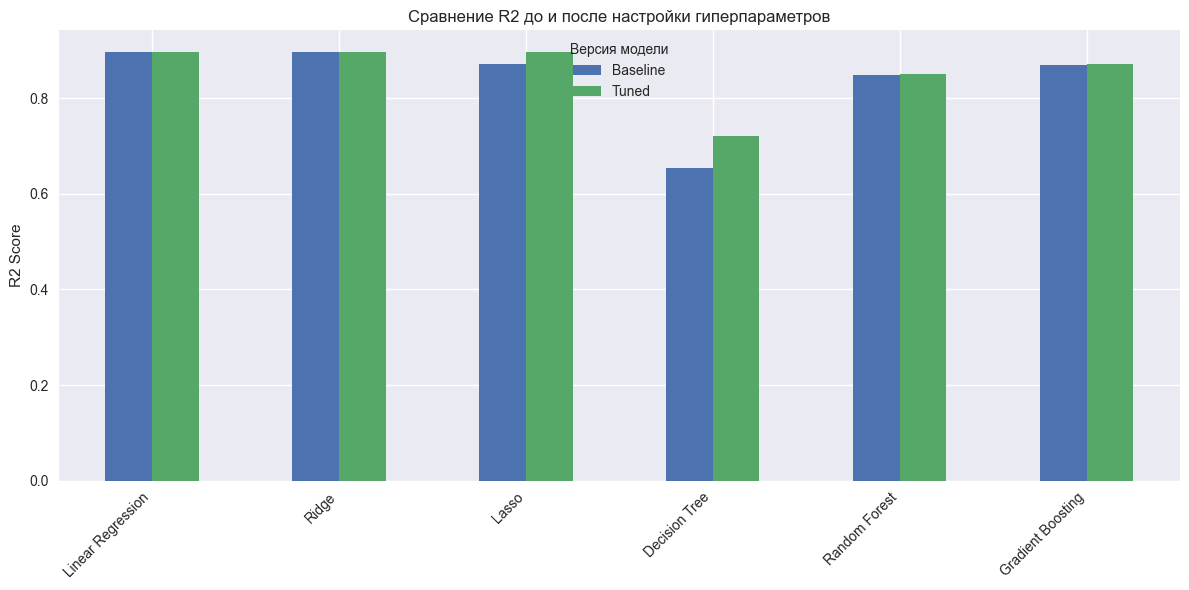

<Figure size 1200x600 with 0 Axes>

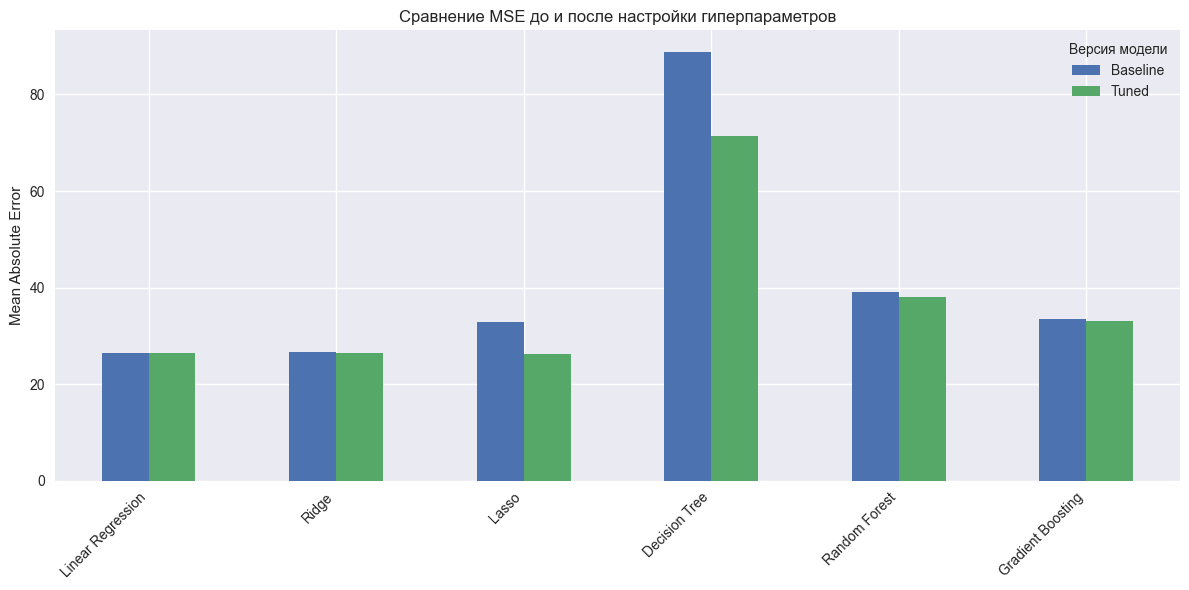


Лучшая модель по R2: Lasso с R2 = 0.8975


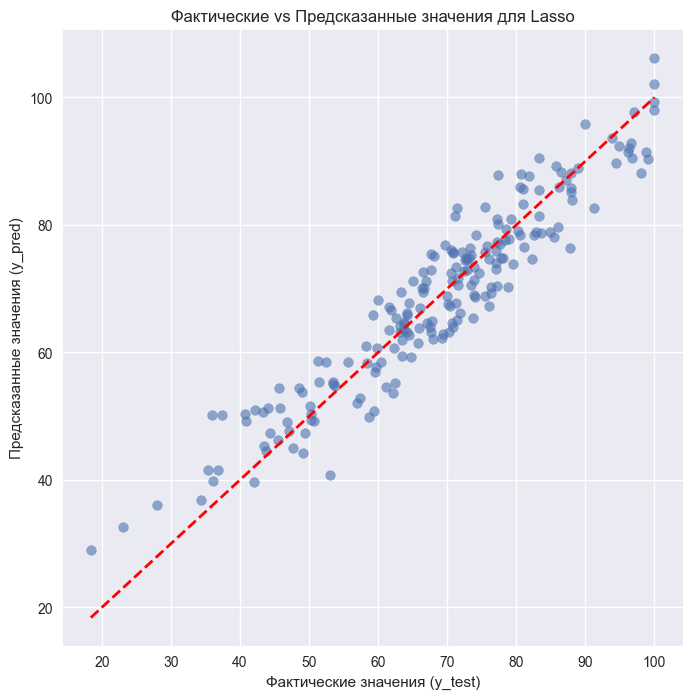

In [ ]:
# Сравнение R2
plt.figure(figsize=(12, 6))
r2_comparison = pd.DataFrame({
    'Baseline': baseline_results_df['R2'],
    'Tuned': tuned_results_df['R2']
})
r2_comparison.plot(kind='bar', figsize=(12, 6))
plt.title("Сравнение R2 до и после настройки гиперпараметров")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Версия модели')
plt.tight_layout()
plt.show()

# Сравнение MAE
plt.figure(figsize=(12, 6))
mae_comparison = pd.DataFrame({
    'Baseline': baseline_results_df['MSE'],
    'Tuned': tuned_results_df['MSE']
})
mae_comparison.plot(kind='bar', figsize=(12, 6))
plt.title("Сравнение MSE до и после настройки гиперпараметров")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Версия модели')
plt.tight_layout()
plt.show()

# Выбор лучшей модели
best_model_name = tuned_results_df['R2'].idxmax()
best_model_r2 = tuned_results_df['R2'].max()
print(f"\nЛучшая модель по R2: {best_model_name} с R2 = {best_model_r2:.4f}")

best_model = best_models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Фактические значения (y_test)")
plt.ylabel("Предсказанные значения (y_pred)")
plt.title(f"Фактические vs Предсказанные значения для {best_model_name}")
plt.grid(True)
plt.show()

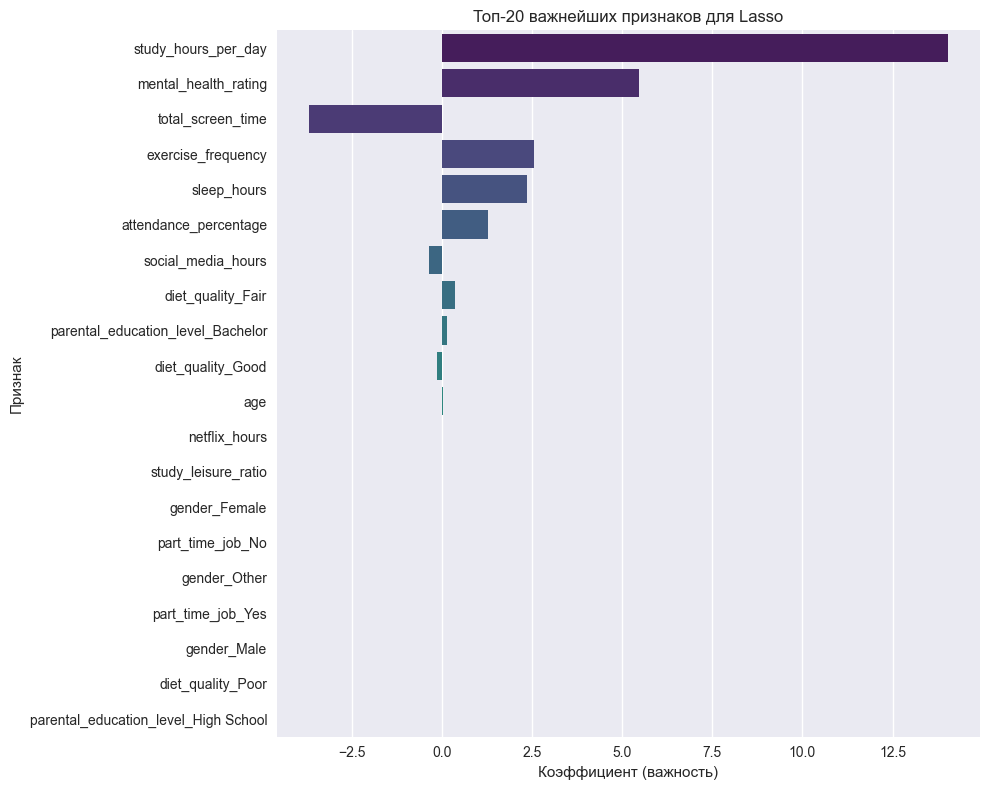

Топ-10 признаков по абсолютной важности:
                              feature  importance
1                 study_hours_per_day   14.041595
7                mental_health_rating    5.462875
8                   total_screen_time   -3.704213
6                  exercise_frequency    2.555648
5                         sleep_hours    2.341929
4               attendance_percentage    1.262386
2                  social_media_hours   -0.382037
15                  diet_quality_Fair    0.346334
18  parental_education_level_Bachelor    0.143854
16                  diet_quality_Good   -0.135985


In [37]:
# Получим имена признаков 
feature_names_num = numerical_cols
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names_cat = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names_num, feature_names_cat])

# Получим коэффициенты Lasso
lasso = best_model.named_steps['regressor']
importances = lasso.coef_

# Визуализируем важности
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', key=np.abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Топ-20 важнейших признаков для Lasso')
plt.xlabel('Коэффициент (важность)')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

print("Топ-10 признаков по абсолютной важности:")
print(importance_df.head(10))

## Итоги работы


### 1. Проведен разведочный анализ данных, выявлены основные характеристики и пропуски.
### 2. Данные были предобработаны: пропуски заполнены, категориальные признаки закодированы, числовые - масштабированы.
### 3. Был проведен корреляционный анализ
### 4. Были выбраны метрики MAE, MSE и R2 для оценки качества регрессионных моделей.
### 5. Были построены и оценены 6 моделей: Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting.
### 6. Проведен подбор гиперпараметров с помощью GridSearchCV, что позволило улучшить для некоторых моделей качество по сравнению с базовыми версиями.
### 7. Удалось добиться отличных результатов достигнув отметки R2 = 0.9 и MAE = 4, что для стобальной шкалы оценивания является хорошим показателем
### 8. В конечном счете лучшей по всем метрикам моделью оказалась Lasso